#🏡✨ [Assignment 4] Polynomial Regression with Scikit-Learn — California Housing Dataset

In this assignment, we’ll explore the famous California Housing dataset 🌴, available on Kaggle:

👉 https://www.kaggle.com/datasets/camnugent/california-housing-prices/data

This dataset contains information about houses — **their location, 🗺️ number of rooms 🛏️**, and more. Alongside these features, we also have the **house price 💵**, which will be our prediction target.

Your task is to:

1.   🟦 Train a baseline model (linear regression).
2.   🟨 Build a polynomial regression model (degree = 2).
3.   🔍 Compare how well each model predicts house prices.

By the end, you’ll see how polynomial regression can capture more complex relationships than a simple straight line 🚀.

## Step 0: Setup

0.    Import Basic modules
1.    Download the dataset (.csv file) from Kaggle link above and upload it to your colab notebook
2.    Load the csv file to a DataFrame called data

In [1]:
#Do NOT change the following code

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data=pd.read_csv("housing.csv")
data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


##Step 1: Linear Correlation

In this step, we will compute the **linear correlation** among the numerical features. Complete the following code by:

1.   Dropping the label column, `median_house_value`.
2.   Dropping any non-numerical columns.
3.   Computing the correlation among the remaining features.

Finally, store the result in a DataFrame named `correlation_matrix`.


In [2]:
### BEGIN SOLUTION
numeric_data = data.drop(columns=["median_house_value"])
numeric_data = numeric_data.select_dtypes(include=[np.number])


correlation_matrix=numeric_data.corr()

### END SOLUTION


In [3]:
#If you have computed the correlation_matrix correclty, the following code should print True
print(correlation_matrix.shape==(8,8))

True


###📉 Dropping Linearly Correlated Features

Run the following code to visualize the linear correlation among the features.


*   🔗 If we find features that are highly correlated linearly (e.g., r > 0.85), we will drop one of them. Why? Because they are not independent and share similar information. Removing one keeps our model simpler — fewer features means fewer parameters to estimate.
*   ❌ On the other hand, if features are not strongly correlated linearly (e.g., r < 0.4), we cannot conclude that they are completely unrelated. They might still be non-linearly correlated, but this step only helps us handle linear redundancy.

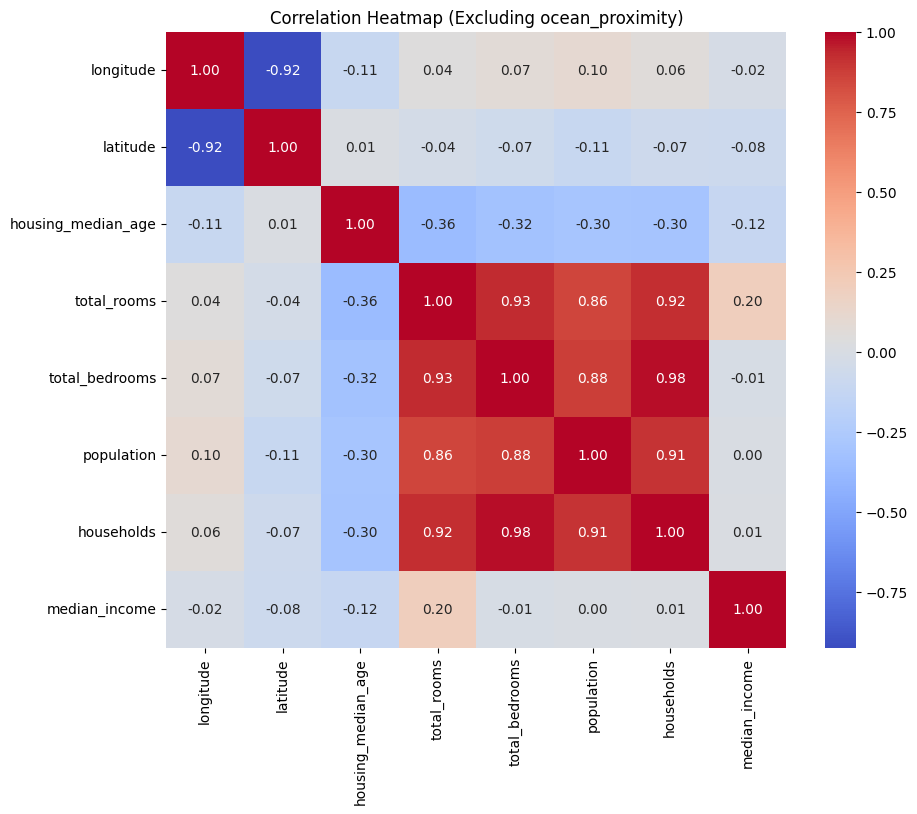

In [4]:
#Do NOT change the following code
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap (Excluding ocean_proximity)')
plt.show()

Based on the linear correlation matrix above, drop the features that are **highly correlated ( r > 0.85)**. Complete the code below so that only the features that are not highly correlated are kept.

Note:

*   Use the **y-axis** of the correlation matrix as the reference. Go from top to bottom: whenever a feature on the y-axis has r > 0.85 with another feature, keep the y-axis feature and remove the correlated one.
*   Don’t forget to drop the non-numerical columns as well as the label column (`median_house_value`).

In [6]:
### BEGIN SOLUTION

X_Raw=data.drop(columns=["median_house_value"])
X_Raw = X_Raw.select_dtypes(include=[np.number])
X_Raw = X_Raw.drop(columns=["latitude", "total_bedrooms", "population", "households"])



### END SOLUTION
X_Raw.head()

,longitude,housing_median_age,total_rooms,median_income
0,-122.23,41.0,880.0,8.3252
1,-122.22,21.0,7099.0,8.3014
2,-122.24,52.0,1467.0,7.2574
3,-122.25,52.0,1274.0,5.6431
4,-122.25,52.0,1627.0,3.8462


## Step 2: Form the features/Label

If you have completed all the steps correctly, you should now see only **4 features** remaining.

If we want to implement the **full second-degree polynomial** with 4 features, the equation should include:

*   each feature,
*   each feature squared, and
*   every pairwise multiplication of the features.

\begin{aligned}
y \approx & \ \theta_0
	•	\theta_1 x_1 + \theta_2 x_2 + \theta_3 x_3 + \theta_4 x_4 \\
& + \theta_5 x_1^2 + \theta_6 x_2^2 + \theta_7 x_3^2 + \theta_8 x_4^2 \\
& + \theta_9 (x_1 x_2) + \theta_{10} (x_1 x_3) + \theta_{11} (x_1 x_4) \\
& + \theta_{12} (x_2 x_3) + \theta_{13} (x_2 x_4) + \theta_{14} (x_3 x_4)
\end{aligned}

In class, we created these polynomial features manually. Here, however, we will use a function called **`PolynomialFeatures`**. This function automatically generates all polynomial terms up to the specified degree. We simply provide it the input features, `X_raw`, and the desired degree, and it creates the expanded feature set for us.

In [7]:
#Do NOT change the following code
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X_Raw)

If you have done everything correctly, the code above will create 15 columns, representing the **15 features** shown in the equation above. The order of these features is:


$$
\
1, \
x_1, \ x_2, \ x_3, \ x_4, \
x_1^2, \ x_1 x_2, \ x_1 x_3, \ x_1 x_4, \
x_2^2, \ x_2 x_3, \ x_2 x_4, \
x_3^2, \ x_3 x_4, \
x_4^2 \
$$

In [8]:
#Run this line of code to see the number of records in the dataset as well as the number of features created.
X_poly.shape

(20640, 15)

In the following code block, we will create a DataFrame named `X` using `X_poly` and add column names. We will also create a DataFrame `Y` from the label column, `median_house_value`. From this point on, working with the data will be much easier.



In [9]:
#Do NOT change the following code
X = pd.DataFrame(X_poly, columns=['1',
 'x1',
 'x2',
 'x3',
 'x4',
 'x1^2',
 'x1 x2',
 'x1 x3',
 'x1 x4',
 'x2^2',
 'x2 x3',
 'x2 x4',
 'x3^2',
 'x3 x4',
 'x4^2'])
Y=pd.DataFrame({'Price':data['median_house_value']})

In [10]:
#Run this code to see the features!
X.head()

,1,x1,x2,x3,x4,x1^2,x1 x2,x1 x3,x1 x4,x2^2,x2 x3,x2 x4,x3^2,x3 x4,x4^2
0,1.0,-122.23,41.0,880.0,8.3252,14940.1729,-5011.43,-107562.40,-1017.589196,1681.0,36080.0,341.3332,774400.0,7326.1760,69.308955
1,1.0,-122.22,21.0,7099.0,8.3014,14937.7284,-2566.62,-867639.78,-1014.597108,441.0,149079.0,174.3294,50395801.0,58931.6386,68.913242
2,1.0,-122.24,52.0,1467.0,7.2574,14942.6176,-6356.48,-179326.08,-887.144576,2704.0,76284.0,377.3848,2152089.0,10646.6058,52.669855
3,1.0,-122.25,52.0,1274.0,5.6431,14945.0625,-6357.00,-155746.50,-689.868975,2704.0,66248.0,293.4412,1623076.0,7189.3094,31.844578
4,1.0,-122.25,52.0,1627.0,3.8462,14945.0625,-6357.00,-198900.75,-470.197950,2704.0,84604.0,200.0024,2647129.0,6257.7674,14.793254


## Step 3: Split the dataset

Import `train_test_split` from Scikit-learn and split the Features(X) and Label(Y) to 70% training subset and 30% test subset



In [16]:
### BEGIN SOLUTION


from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.30, random_state=42
    )



### END SOLUTION

You should have 4 variables at this point: X_train, X_test, Y_train, Y_test

Step 4: Form Your Models

In this step, we will build two regression models to be trained later:

*   Import the `LinearRegression` class from `sklearn.linear_model`.
*   Create a linear regression model named `Model_Linear_Baseline` (to be trained on the raw features)
*   Create a linear regression model named `Model_Polynomial_Degree_2` (to be trained on the polynomial features in `X_poly`)

In [17]:
### BEGIN SOLUTION
from sklearn.linear_model import LinearRegression



Model_Linear_BaseLine = LinearRegression()
Model_Polynomial_Degree_2 = LinearRegression()



### END SOLUTION

## Step 5: Train your model

Train your linear model only using the first 5 features in **X_train**, ['1',
 'x1',
 'x2',
 'x3',
 'x4']


 and train your polynomial model using all features in **X_train** and your label **Y_train**

In [19]:
### BEGIN SOLUTION

Model_Linear_BaseLine.fit(X_train.iloc[:, :5], Y_train)

# Train polynomial regression using all polynomial features
Model_Polynomial_Degree_2.fit(X_train, Y_train)



### END SOLUTION

LinearRegression()

## Step 6: Check the Coefficients

Print all 5 parameters; coefficients and intercept of the linear model <BR>
Print all 15 parameters; coefficients and intercept of the Polynomial model

In [25]:
### BEGIN SOLUTION

print(Model_Linear_BaseLine.coef_)
print(Model_Linear_BaseLine.intercept_)
print(Model_Polynomial_Degree_2.coef_)
print(Model_Polynomial_Degree_2.intercept_)



### END SOLUTION

[[ 0.00000000e+00 -9.95513585e+02  1.96877592e+03  4.09016306e+00
   4.24100078e+04]]
[-143619.37903203]
[[ 0.00000000e+00 -2.23080069e+05 -1.36462384e+04 -2.30818260e+01
  -8.49076444e+04 -9.58961843e+02 -9.36143645e+01 -8.38582040e-02
  -1.10923750e+03  4.32568995e+01  5.59416944e-01  1.65924612e+02
   3.59975675e-05  1.48386108e+00 -1.36553781e+03]]
[-12921602.67231541]


## Step 7: Predictions

Use the trained models to predict the house prices for the trainig subset and test subset

In [26]:
### BEGIN SOLUTION



Baseline_test_predictions  = Model_Linear_BaseLine.predict(X_test.iloc[:, :5])
Baseline_train_predictions = Model_Linear_BaseLine.predict(X_train.iloc[:, :5])

Polynomial_test_predictions  = Model_Polynomial_Degree_2.predict(X_test)
Polynomial_train_predictions = Model_Polynomial_Degree_2.predict(X_train)



### END SOLUTION

## Step 8: Residual Analysis - Error


In this step, you will calculate the residuals (the absolute difference between predicted values and actual values) for both models:

**Baseline Model (Linear)**
*   For the testing subset, store the residuals in a variable named `Baseline_test_res`.
*   For the training subset, store the residuals in a variable named `Baseline_train_res`.

**Polynomial Model (Degree 2)**
*   For the testing subset, store the residuals in a variable named `Polynomial_test_res`.
*   For the training subset, store the residuals in a variable named `Polynomial_train_res`.

In [29]:
### BEGIN SOLUTION




Baseline_test_res  = np.abs(Y_test.values.flatten()  - Baseline_test_predictions.flatten())
Baseline_train_res = np.abs(Y_train.values.flatten() - Baseline_train_predictions.flatten())

Polynomial_test_res  = np.abs(Y_test.values.flatten()  - Polynomial_test_predictions.flatten())
Polynomial_train_res = np.abs(Y_train.values.flatten() - Polynomial_train_predictions.flatten())


### END SOLUTION

Run the following code block to visualize the distribution of the residuals. If you calculated the residuals correct, the plots should show up!

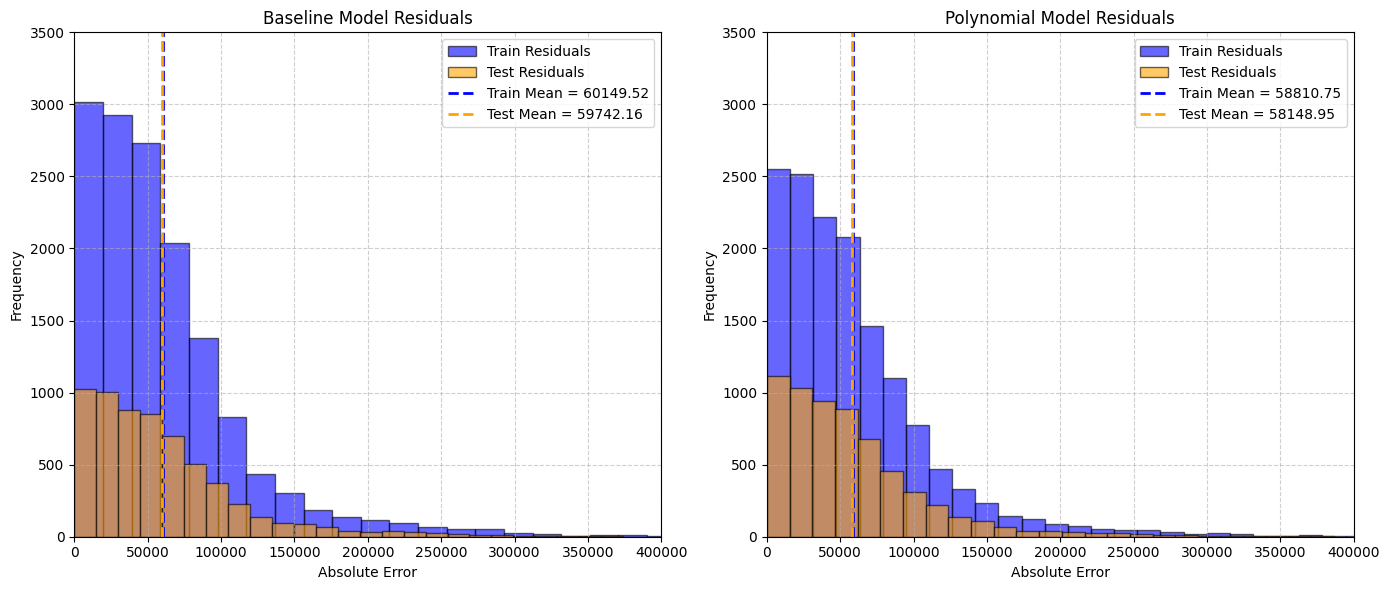

In [30]:
# Compute means (MAE) ~Mean Absolute Error
Baseline_train_mae = np.mean(Baseline_train_res)
Baseline_test_mae  = np.mean(Baseline_test_res)

Polynomial_train_mae = np.mean(Polynomial_train_res)
Polynomial_test_mae  = np.mean(Polynomial_test_res)

plt.figure(figsize=(14,6))

# --- Baseline model ---
plt.subplot(1,2,1)
plt.hist(Baseline_train_res, bins=30, alpha=0.6, color='blue', edgecolor='black', label='Train Residuals')
plt.hist(Baseline_test_res, bins=30, alpha=0.6, color='orange', edgecolor='black', label='Test Residuals')

# Mean error lines
plt.axvline(Baseline_train_mae, color='blue', linestyle='dashed', linewidth=2,
            label=f"Train Mean = {Baseline_train_mae:.2f}")
plt.axvline(Baseline_test_mae, color='orange', linestyle='dashed', linewidth=2,
            label=f"Test Mean = {Baseline_test_mae:.2f}")

plt.xlabel("Absolute Error")
plt.ylabel("Frequency")
plt.title("Baseline Model Residuals")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Fix axes
plt.xlim(0, 400000)
plt.ylim(0, 3500)

# --- Polynomial model ---
plt.subplot(1,2,2)
plt.hist(Polynomial_train_res, bins=30, alpha=0.6, color='blue', edgecolor='black', label='Train Residuals')
plt.hist(Polynomial_test_res, bins=30, alpha=0.6, color='orange', edgecolor='black', label='Test Residuals')

# Mean error lines
plt.axvline(Polynomial_train_mae, color='blue', linestyle='dashed', linewidth=2,
            label=f"Train Mean = {Polynomial_train_mae:.2f}")
plt.axvline(Polynomial_test_mae, color='orange', linestyle='dashed', linewidth=2,
            label=f"Test Mean = {Polynomial_test_mae:.2f}")

plt.xlabel("Absolute Error")
plt.ylabel("Frequency")
plt.title("Polynomial Model Residuals")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Fix axes
plt.xlim(0, 400000)
plt.ylim(0, 3500)

plt.tight_layout()
plt.show()

**<font color=blue>Do you see the Improvement?!**

##Step 9: Mean Squared Error (MSE) Analysis

In this step, you will calculate the Mean Squared Error (MSE) for both models:

**Baseline Model (Linear)**
*   For the testing subset, compute the MSE and store it in a variable named `Baseline_test_mse`.
*   For the training subset, compute the MSE and store it in a variable named `Baseline_train_mse`.

**Polynomial Model (Degree 2)**
*   For the testing subset, compute the MSE and store it in a variable named
`Polynomial_test_mse`.
*   For the training subset, compute the MSE and store it in a variable named `Polynomial_train_mse`.



In [31]:
### BEGIN SOLUTION

# Baseline model MSE
Baseline_test_mse  = np.mean((Y_test.values.flatten()  - Baseline_test_predictions.flatten())**2)
Baseline_train_mse = np.mean((Y_train.values.flatten() - Baseline_train_predictions.flatten())**2)

# Polynomial model MSE
Polynomial_test_mse  = np.mean((Y_test.values.flatten()  - Polynomial_test_predictions.flatten())**2)
Polynomial_train_mse = np.mean((Y_train.values.flatten() - Polynomial_train_predictions.flatten())**2)

### END SOLUTION

Run the following code to visualize the MSE improvement!

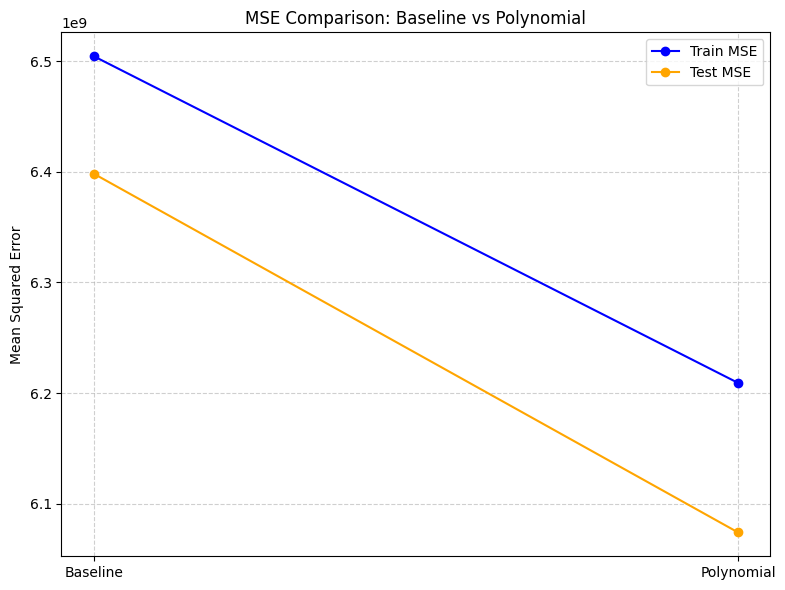

In [32]:
# Models
models = ["Baseline", "Polynomial"]

# Train and Test MSE values
train_mse = [Baseline_train_mse, Polynomial_train_mse]
test_mse  = [Baseline_test_mse, Polynomial_test_mse]

# Plot
plt.figure(figsize=(8,6))
plt.plot(models, train_mse, marker='o', color='blue', label='Train MSE')
plt.plot(models, test_mse, marker='o', color='orange', label='Test MSE')

plt.ylabel("Mean Squared Error")
plt.title("MSE Comparison: Baseline vs Polynomial")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()